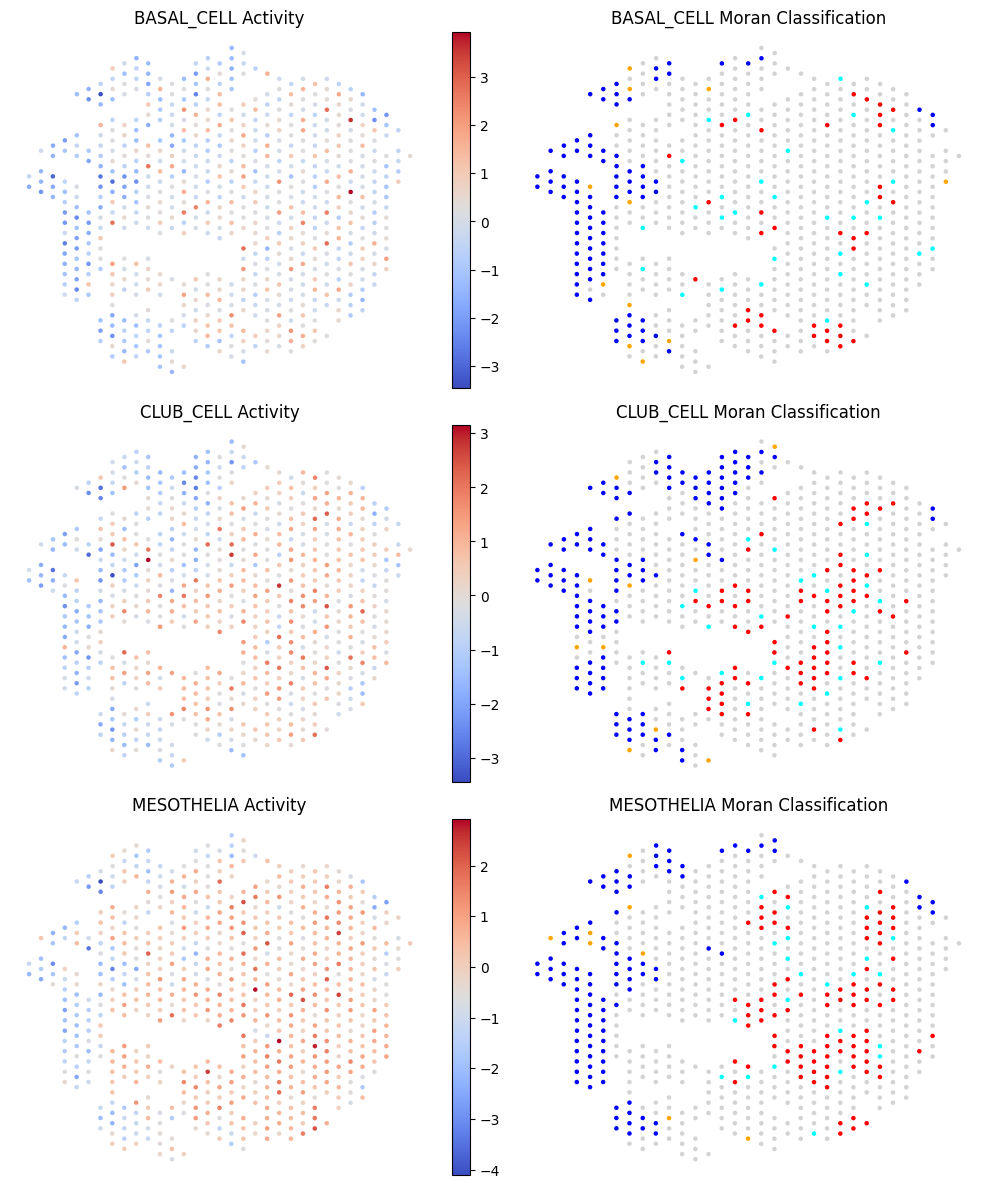

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


'''
(1) spatial pathway heatmap
(2) Moran hotspot classification map
'''

df = pd.read_csv('data/p016_lung_1_tumor_unimoran_basal_cell_report.csv')


pathways_to_plot = [
    "BASAL_CELL",
    "CLUB_CELL",
    "MESOTHELIA"
]


moran_colors = {
    0: "lightgray",   # Not significant
    1: "red",         # High-High
    2: "blue",        # Low-Low
    3: "cyan",        # Low-High
    4: "orange"       # High-Low
}


fig, axes = plt.subplots(
    len(pathways_to_plot), 
    2, 
    figsize=(10, 4 * len(pathways_to_plot))
)


for i, pathway in enumerate(pathways_to_plot):


    ax1 = axes[i, 0]

    sc = ax1.scatter(
        df["x"],
        df["y"],
        c=df[pathway],
        cmap="coolwarm",
        s=5
    )

    ax1.set_title(f"{pathway} Activity")
    ax1.invert_yaxis()
    ax1.axis("off")

    plt.colorbar(sc, ax=ax1, fraction=0.046)

    ax2 = axes[i, 1]

    colors = df[f"{pathway}_quad (sig=0.05)"].map(moran_colors)

    ax2.scatter(
        df["x"],
        df["y"],
        c=colors,
        s=5
    )

    ax2.set_title(f"{pathway} Moran Classification")
    ax2.invert_yaxis()
    ax2.axis("off")

plt.tight_layout()
plt.savefig('test.png', dpi=300)
plt.show()


<Figure size 1200x1000 with 0 Axes>

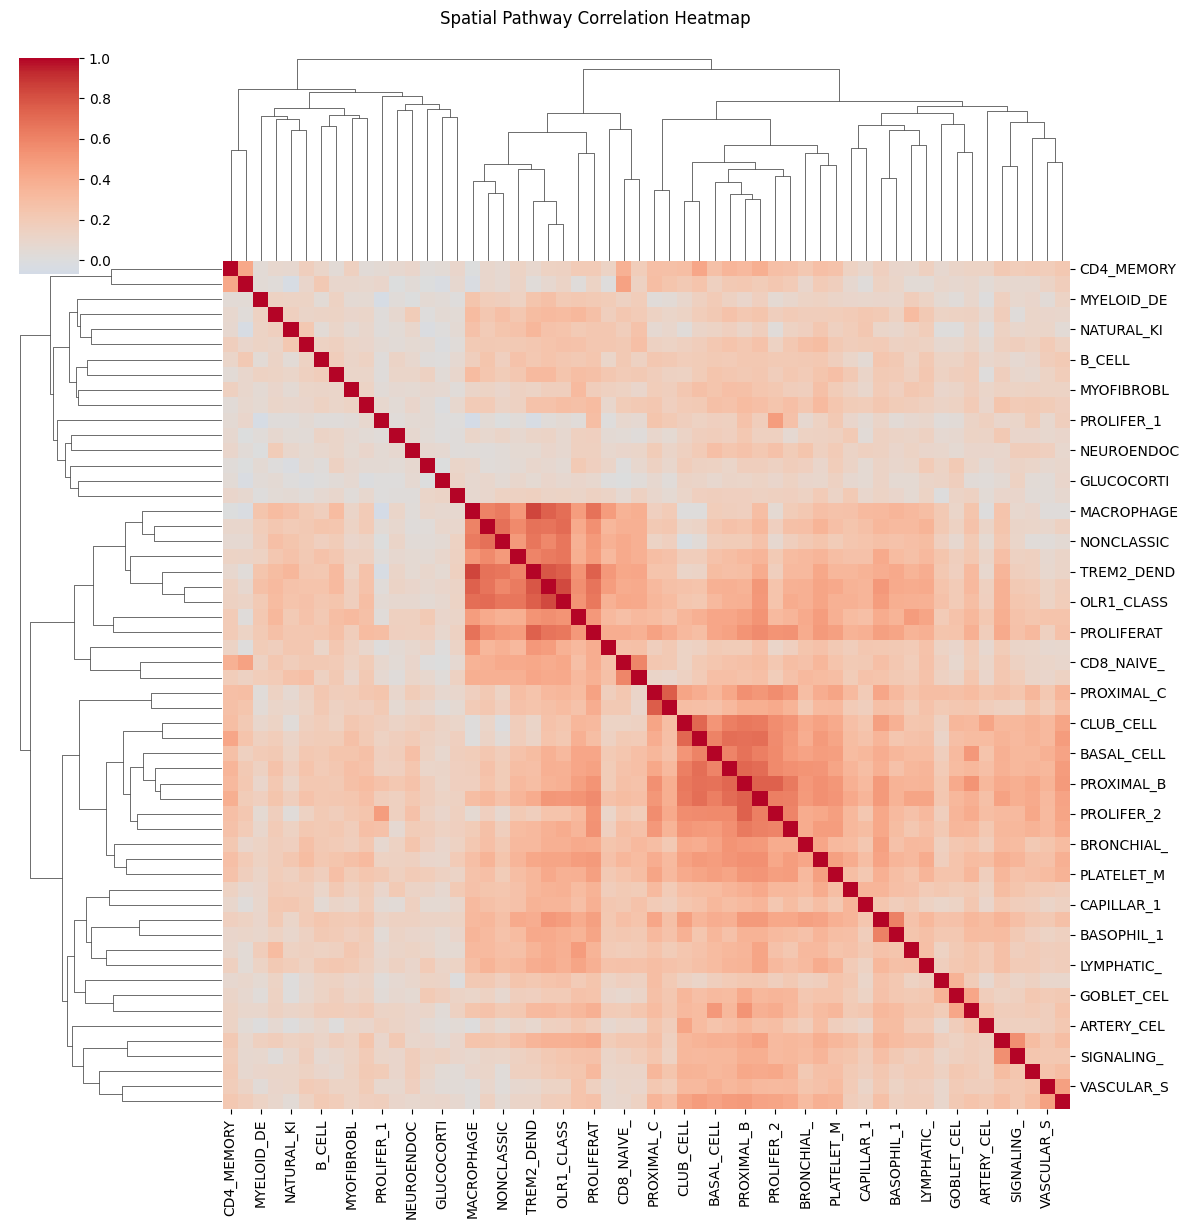

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

exclude_cols = ["barcode", "x", "y", "quad (sig=0.05)", "labels (sig=0.05)"]
pathway_cols = [c for c in df.columns if c not in exclude_cols]

corr_matrix = df[pathway_cols].corr(method="pearson")

plt.figure(figsize=(12,10))

sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(12,12)
)

plt.suptitle("Spatial Pathway Correlation Heatmap", y=1.02)
plt.show()


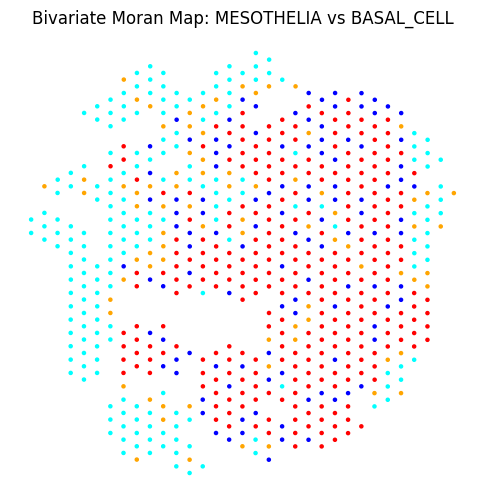

In [5]:
from libpysal.weights import KNN
from esda.moran import Moran_Local_BV
import matplotlib.pyplot as plt

pathway_A = "MESOTHELIA"
pathway_B = "BASAL_CELL"

coords = list(zip(df["x"], df["y"]))
w = KNN.from_array(coords, k=6)
w.transform = "r"

values_A = df[pathway_A].values
values_B = df[pathway_B].values

moran_bv = Moran_Local_BV(values_A, values_B, w)

df["biv_quad"] = moran_bv.q
df["biv_pval"] = moran_bv.p_sim

biv_colors = {
    0: "lightgray",
    1: "red",     # High A - High B
    2: "blue",    # Low A - Low B
    3: "cyan",    # Low A - High B
    4: "orange"   # High A - Low B
}

colors = df["biv_quad"].map(biv_colors)
plt.figure(figsize=(6,6))
plt.scatter(
    df["x"],
    df["y"],
    c=colors,
    s=5
)

plt.gca().invert_yaxis()
plt.title(f"Bivariate Moran Map: {pathway_A} vs {pathway_B}")
plt.axis("off")

plt.show()


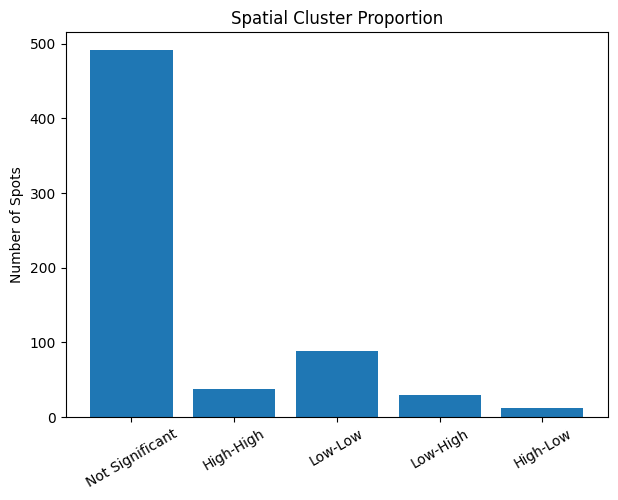

In [4]:
import matplotlib.pyplot as plt

cluster_counts = df["quad (sig=0.05)"].value_counts().sort_index()

labels_map = {
    0: "Not Significant",
    1: "High-High",
    2: "Low-Low",
    3: "Low-High",
    4: "High-Low"
}

labels = [labels_map[i] for i in cluster_counts.index]

plt.figure(figsize=(7,5))

plt.bar(labels, cluster_counts.values)
plt.ylabel("Number of Spots")
plt.title("Spatial Cluster Proportion")

plt.xticks(rotation=30)
plt.show()


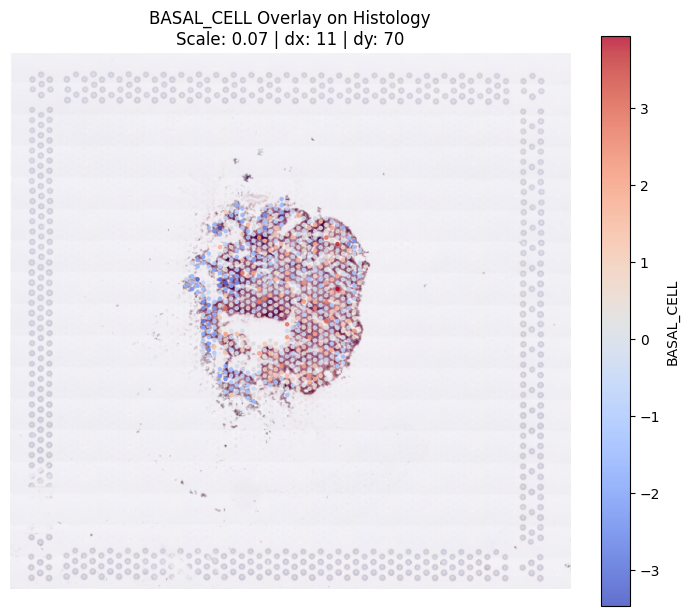

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("tissue_lowres_image.png")
#pathway = "MACROPHAGE"
pathway = "BASAL_CELL"

scale_factor = 0.07
dx = 11 
dy = 70  


aligned_x = (df["x"] * scale_factor) + dx
aligned_y = (df["y"] * scale_factor) + dy

plt.figure(figsize=(8, 8))

plt.imshow(img)

plt.scatter(
    aligned_x,
    aligned_y,
    c=df[pathway],
    cmap="coolwarm",
    s=5, 
    alpha=0.8
)

plt.colorbar(label=pathway, fraction=0.046)
plt.title(f"{pathway} Overlay on Histology\nScale: {scale_factor} | dx: {dx} | dy: {dy}")
plt.axis("off")

plt.show()

--- Class Counts ---
labels (sig=0.05)
Not Significant    491
Low-Low             89
High-High           37
Low-High            30
High-Low            12
Name: count, dtype: int64


--- Contiguity & Region Analysis ---
Class: High-High
  Total Spots: 37
  Is entirely contiguous? False
  Number of sub-graphs (regions): 13
  All region sizes: [8, 6, 6, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1]
------------------------------
Class: Low-Low
  Total Spots: 89
  Is entirely contiguous? False
  Number of sub-graphs (regions): 7
  All region sizes: [61, 10, 7, 4, 3, 3, 1]
------------------------------
Class: Low-High
  Total Spots: 30
  Is entirely contiguous? False
  Number of sub-graphs (regions): 28
  All region sizes: [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
------------------------------


C:\Users\Liangcheng Sun\AppData\Local\Temp\ipykernel_34380\3689781989.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', max(20, num_components))


Class: High-Low
  Total Spots: 12
  Is entirely contiguous? False
  Number of sub-graphs (regions): 11
  All region sizes: [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
------------------------------


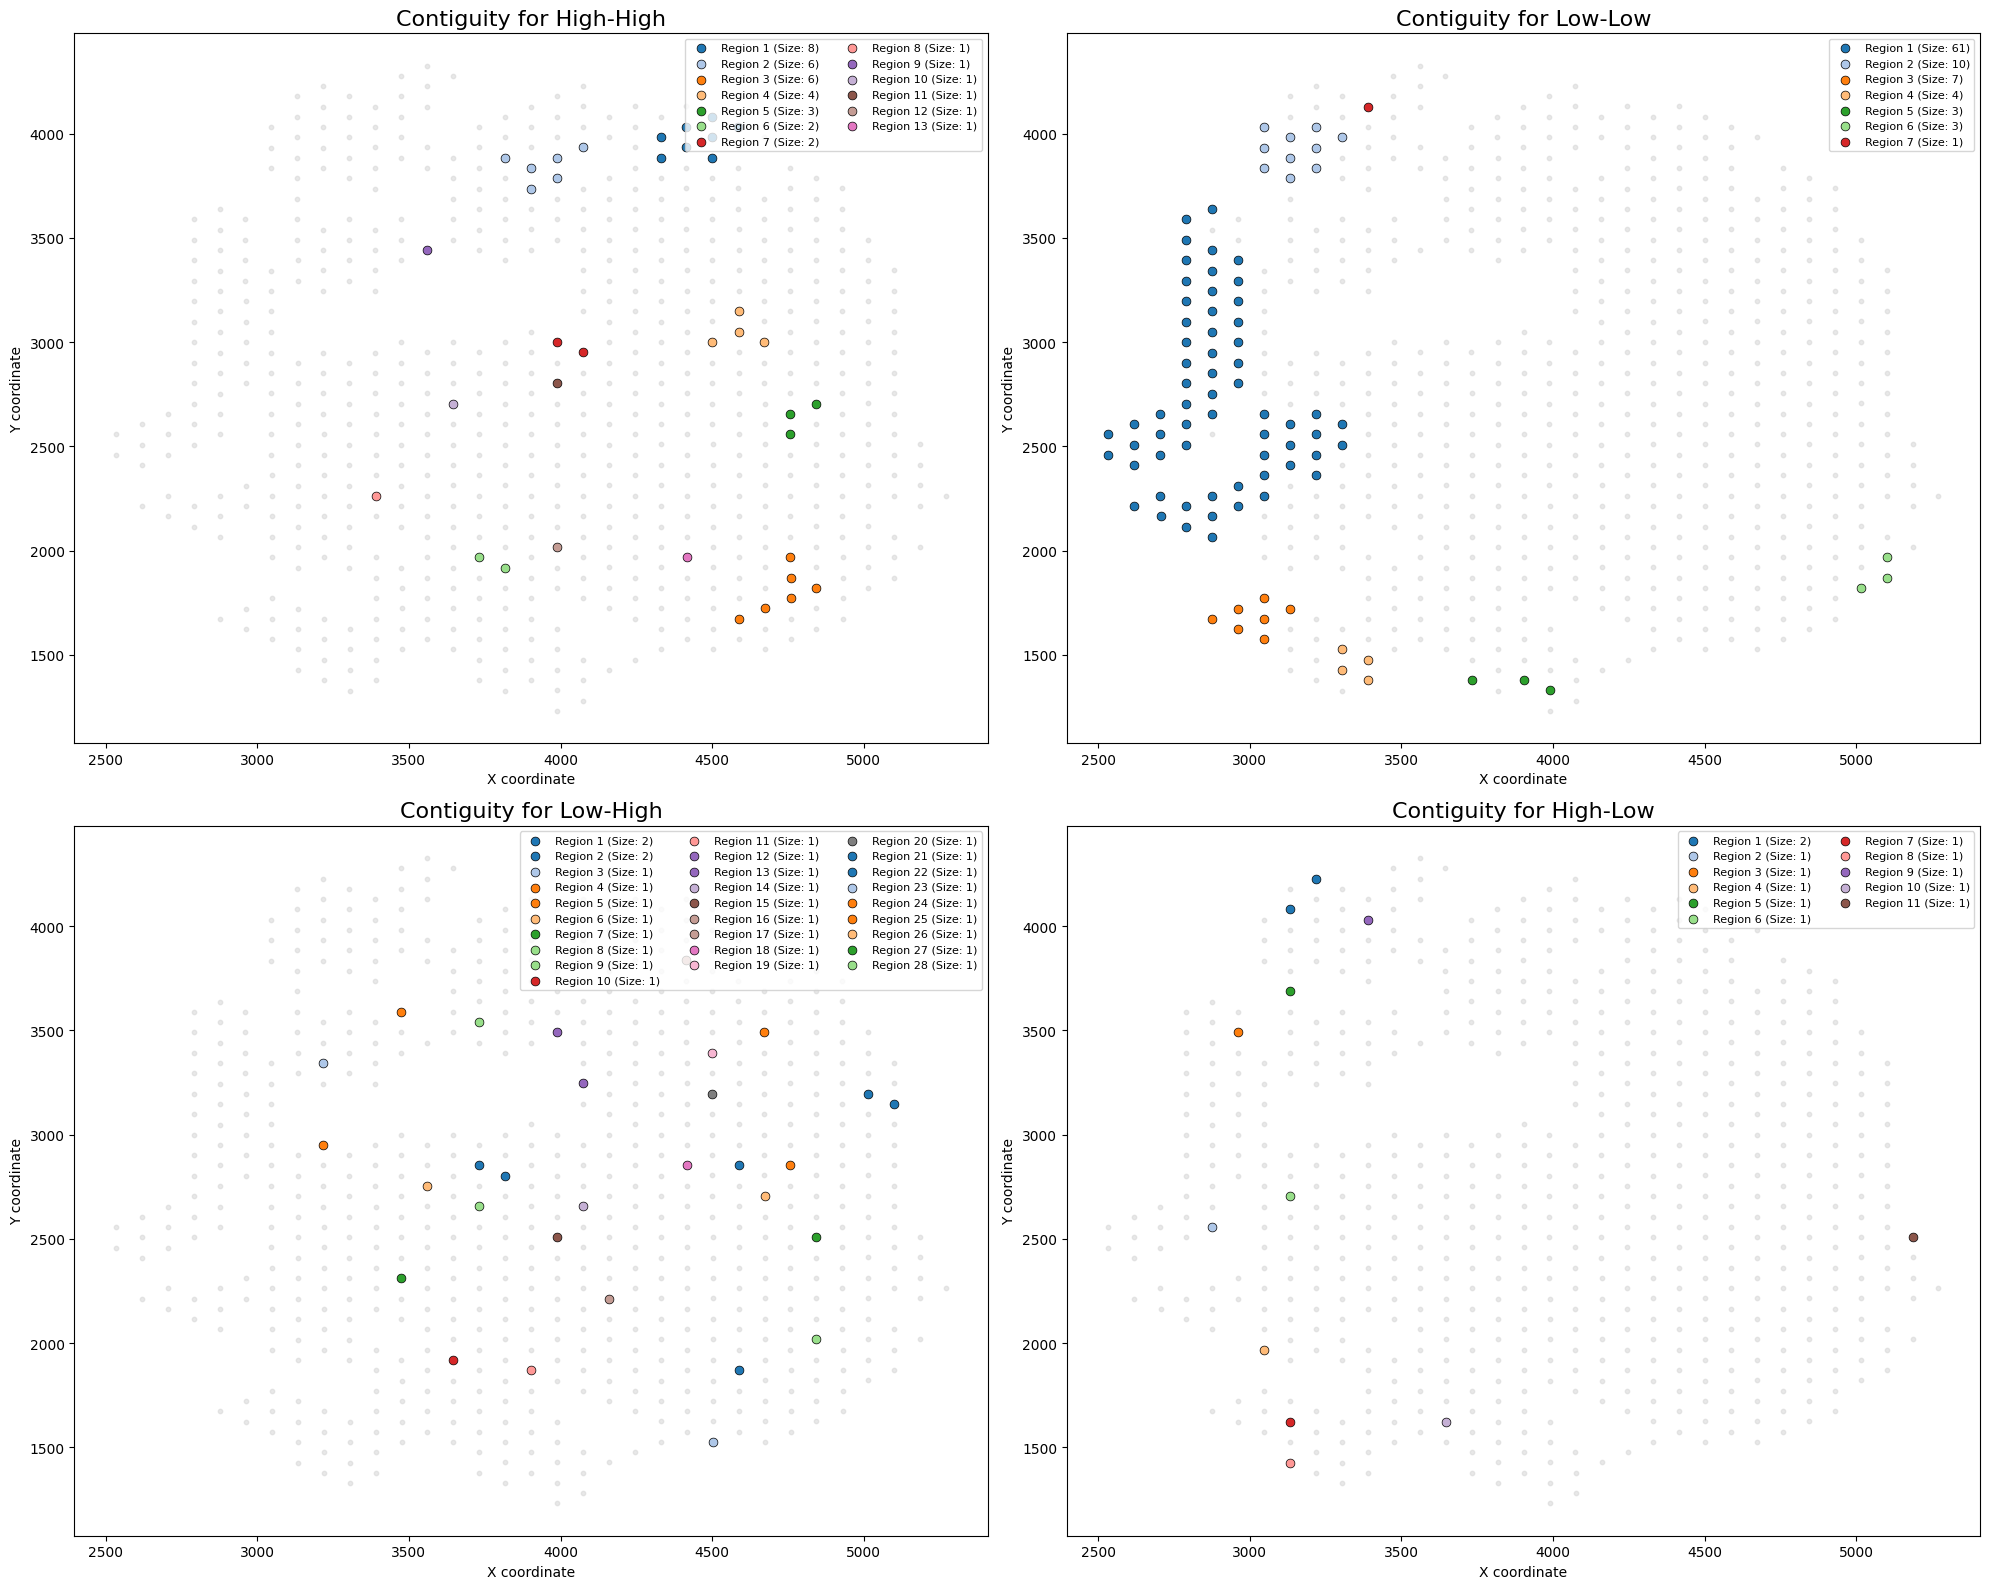

In [7]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

df = pd.read_csv('data/p016_lung_1_tumor_unimoran_basal_cell_report.csv')
coords = df[['x', 'y']].values

nn = NearestNeighbors(n_neighbors=7)
nn.fit(coords)
distances, indices = nn.kneighbors(coords)

class_counts = df['labels (sig=0.05)'].value_counts()
print("--- Class Counts ---")
print(class_counts)
print("\n")

classes_to_check = ['High-High', 'Low-Low', 'Low-High', 'High-Low']

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

print("--- Contiguity & Region Analysis ---")
for i, cls in enumerate(classes_to_check):
    ax = axes[i]
    ax.scatter(df['x'], df['y'], c='lightgray', s=10, alpha=0.5)
    ax.set_title(f'Contiguity for {cls}', fontsize=16)
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    
    if cls not in class_counts.index:
        continue
        
    cls_indices = df[df['labels (sig=0.05)'] == cls].index.values
    cls_set = set(cls_indices)
    
    G = nx.Graph()
    G.add_nodes_from(cls_indices)
    
    for idx in cls_indices:
        neighbors = indices[idx, 1:]
        for n in neighbors:
            if n in cls_set:
                G.add_edge(idx, n)
                
    components = list(nx.connected_components(G))
    num_components = len(components)
    component_sizes = sorted([len(c) for c in components], reverse=True)
    
    print(f"Class: {cls}")
    print(f"  Total Spots: {len(cls_indices)}")
    print(f"  Is entirely contiguous? {num_components == 1}")
    print(f"  Number of sub-graphs (regions): {num_components}")
    print(f"  All region sizes: {component_sizes}")
    print("-" * 30)
    
    cmap = plt.cm.get_cmap('tab20', max(20, num_components))
    for j, comp in enumerate(sorted(components, key=len, reverse=True)):
        comp_list = list(comp)
        label_text = f'Region {j+1} (Size: {len(comp_list)})'
        
        ax.scatter(
            df['x'].iloc[comp_list], 
            df['y'].iloc[comp_list], 
            s=40, 
            color=cmap(j % 20), 
            edgecolors='black', 
            linewidth=0.5,
            label=label_text
        )
    
    if num_components > 0:
        cols = 1
        if num_components > 10:
            cols = 2
        if num_components > 20:
            cols = 3
        ax.legend(loc='upper right', fontsize=8, ncol=cols)

plt.tight_layout()
plt.savefig('contiguity_analysis_all.png')
plt.show()